In [1]:
import pandas as pd
import numpy as np

import tubesml as tml


import matplotlib.pyplot as plt
%matplotlib inline

from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.metrics import accuracy_score, log_loss, brier_score_loss

from source.report import report_points, report_victory, _point_to_proba


from sklearn.model_selection import KFold

from sklearn.linear_model import Ridge, LogisticRegression, Lasso
from sklearn.pipeline import Pipeline

import lightgbm as lgb
import xgboost as xgb

In [2]:
def train_predict(data, test_data, target, estimator, cv, test_target=None, fit_params=None, early_stopping=False, shap=True, result_compare=None):
    cv_score = tml.CrossValidate(data=data, target=target, test=test_data,
                                 estimator=estimator, cv=cv, fit_params=fit_params, early_stopping=early_stopping,
                                shap=shap, imp_coef=True)

    oof, pred, result_dict = cv_score.score()

    score = np.sqrt(mean_squared_error(y_true=target, y_pred=oof))
    print(f"OOF score: {score}")

    if early_stopping:
        print(result_dict["iterations"])

    if shap:
        tml.plot_feat_imp(result_dict["feat_imp"], imp="both", n=10)
        to_plot = result_dict["feat_imp"].head(10)["Feature"].to_list()
        tml.plot_shap_values(result_dict["shap_values"], features=to_plot)
    else:
        tml.plot_feat_imp(result_dict["feat_imp"], imp="standard", n=10)

    tml.plot_regression_predictions(data=data, true_label=target, pred_label=oof, feature=["delta_Seed"])

    if result_compare is not None:
        baseline = result_compare["score"]
        ref_oof = result_compare["oof"]

        if score - baseline >= 0:
            print(f"This is {round((score - baseline) / baseline * 100, 3)}% worse than the baseline.")
        else:
            print(f"This is {round(-(score - baseline) / baseline * 100, 3)}% better than the baseline.")
    
        comparison = tml.CompareModels(data=data, true_label=target.reset_index(drop=True),
                                       pred_1=oof, pred_2=ref_oof,
                                       kfold=cv,
                                       regression=True,
                                       probabilities=True,
                                       metric_func=mean_squared_error)
    
        comparison.compare_metrics()
        comparison.compare_predictions()
        comparison.statistical_significance()

    if test_target is not None:
        score = np.sqrt(mean_squared_error(y_true=test_target, y_pred=pred))
        print(f"Test score: {score}")
        tml.plot_regression_predictions(data=test_data, true_label=test_target, pred_label=pred, feature=["delta_Seed"])

    return oof, pred, result_dict

In [3]:
df = pd.read_csv("data/processed/men_training.csv")

DROP = ["target", "target_points", "ID", "DayNum", "Team1", "Team2",
        'T1_Loc', 'T2_Loc',
                "T1_region", "T2_region", "Season", "delta_Loc",
                "Season", "competitive", "competitive_score",
                "delta_def_rating_diff", "delta_impact_diff",
                "T1_def_rating_diff", "T2_def_rating_diff"]


N_FOLDS = 5
kfolds = KFold(n_splits=N_FOLDS, shuffle=True, random_state=13)

df_train, df_test = tml.make_test(df, test_size=0.2, random_state=34)

OOF score: 11.296214664903918


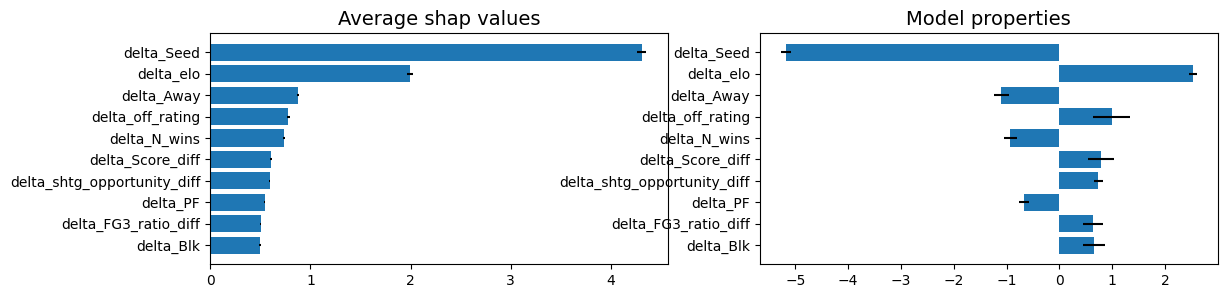

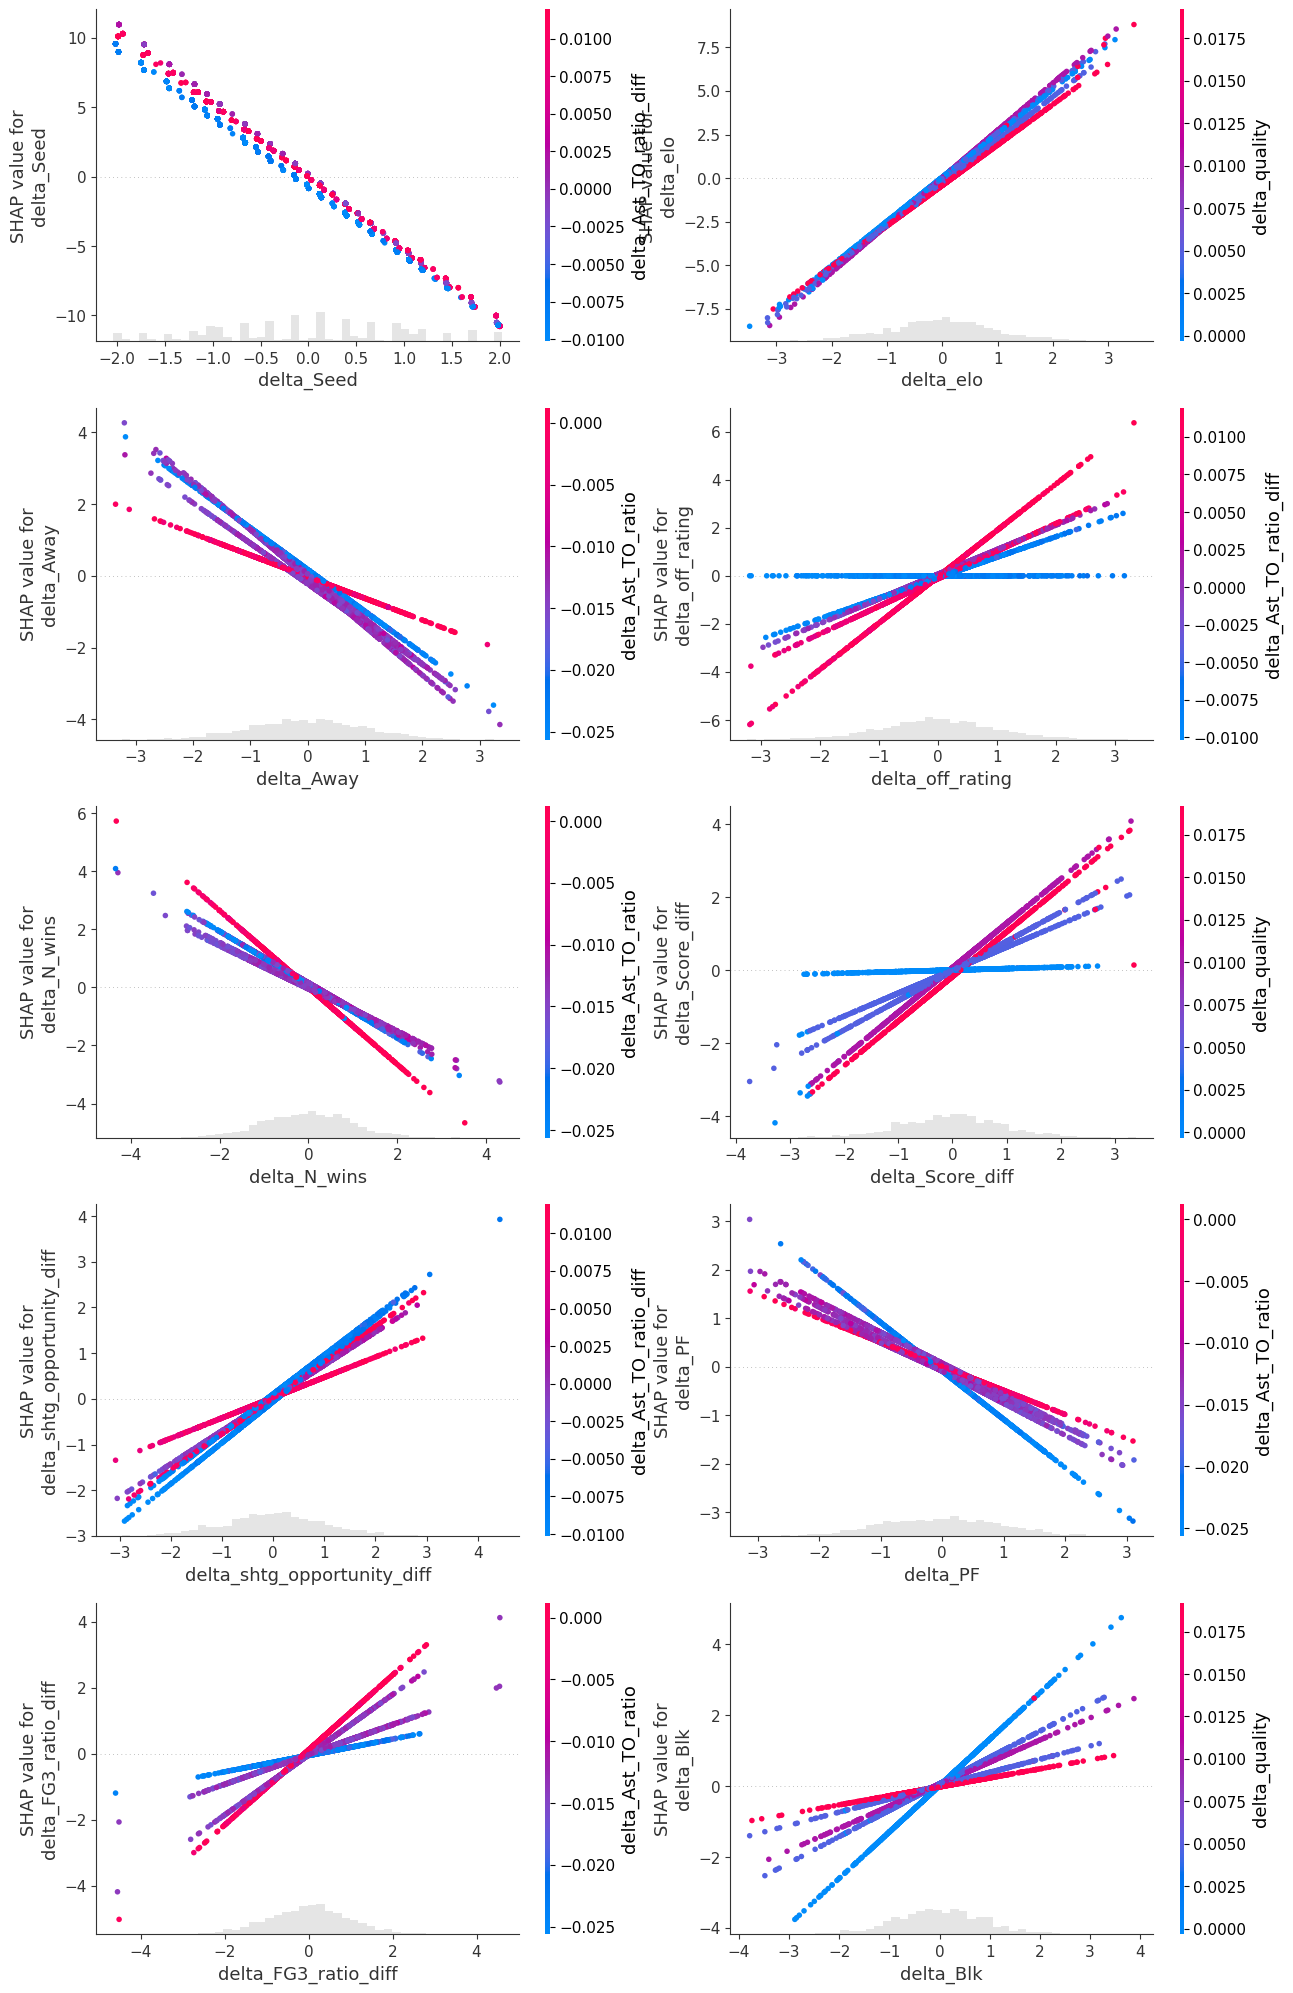

use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.


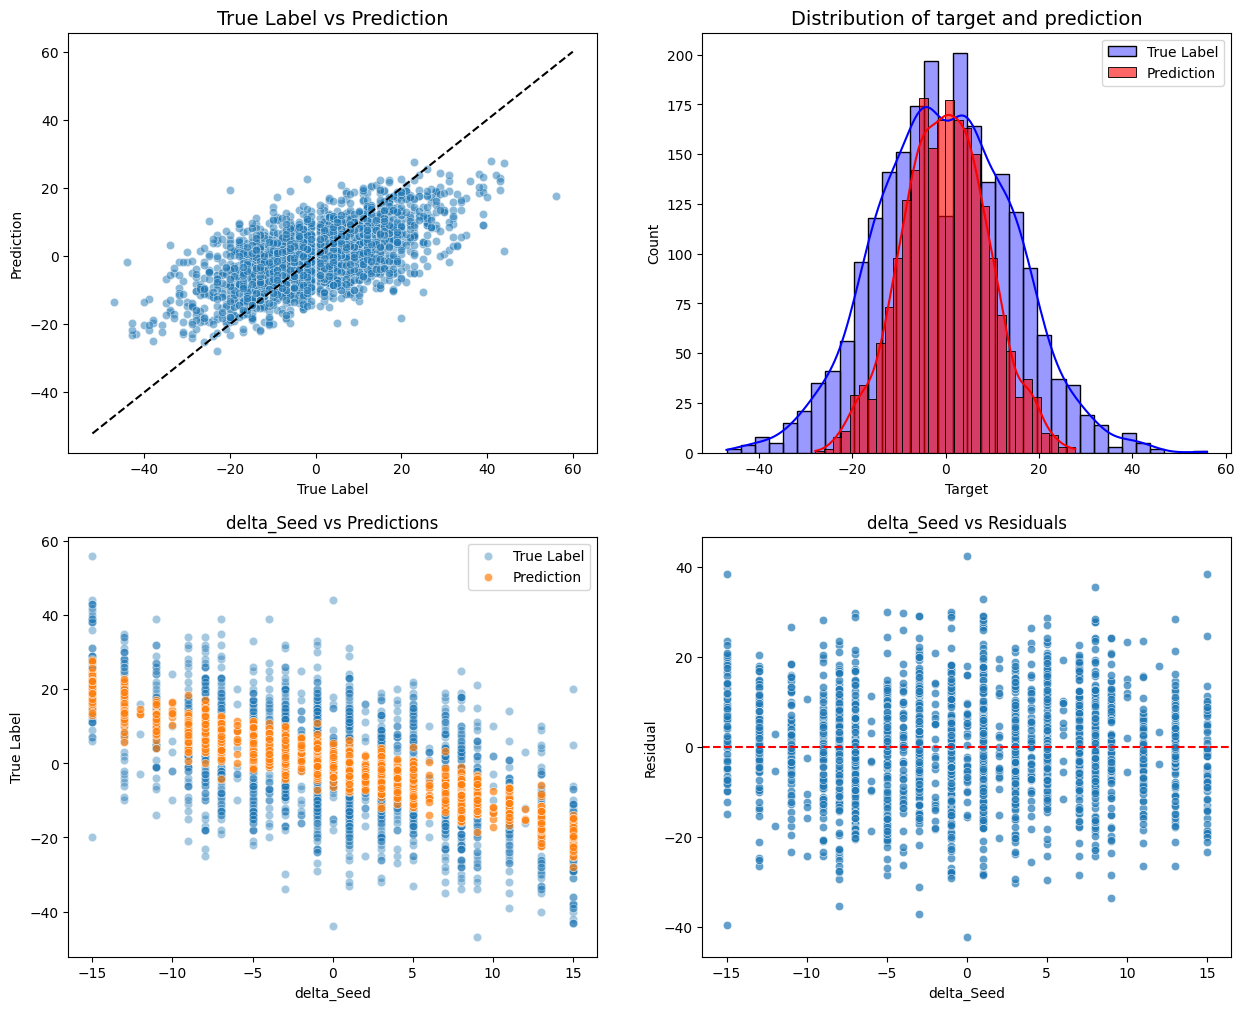

Test score: 11.784320969506258


use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.


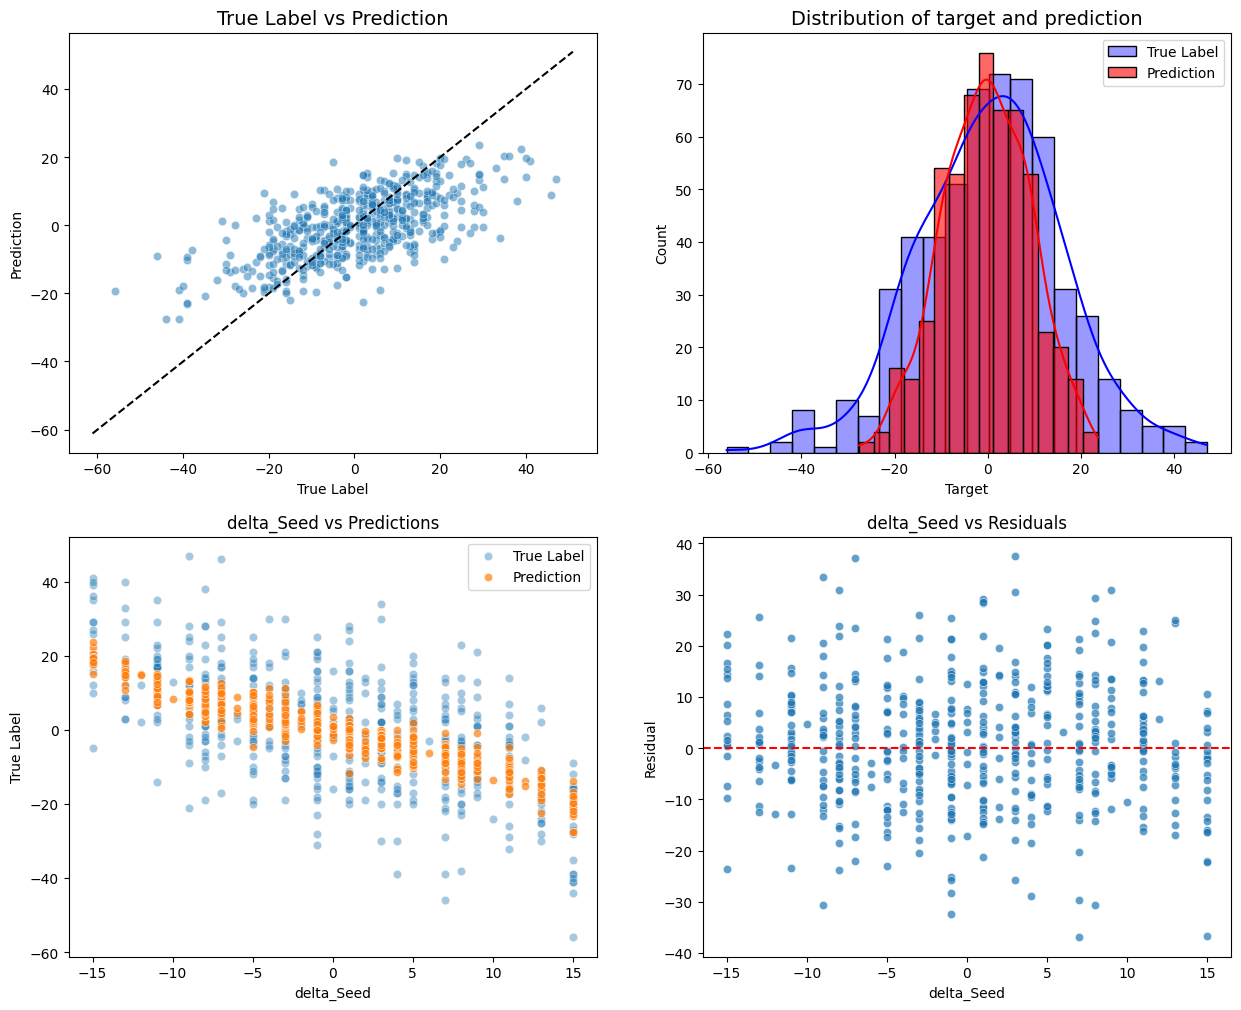

use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.


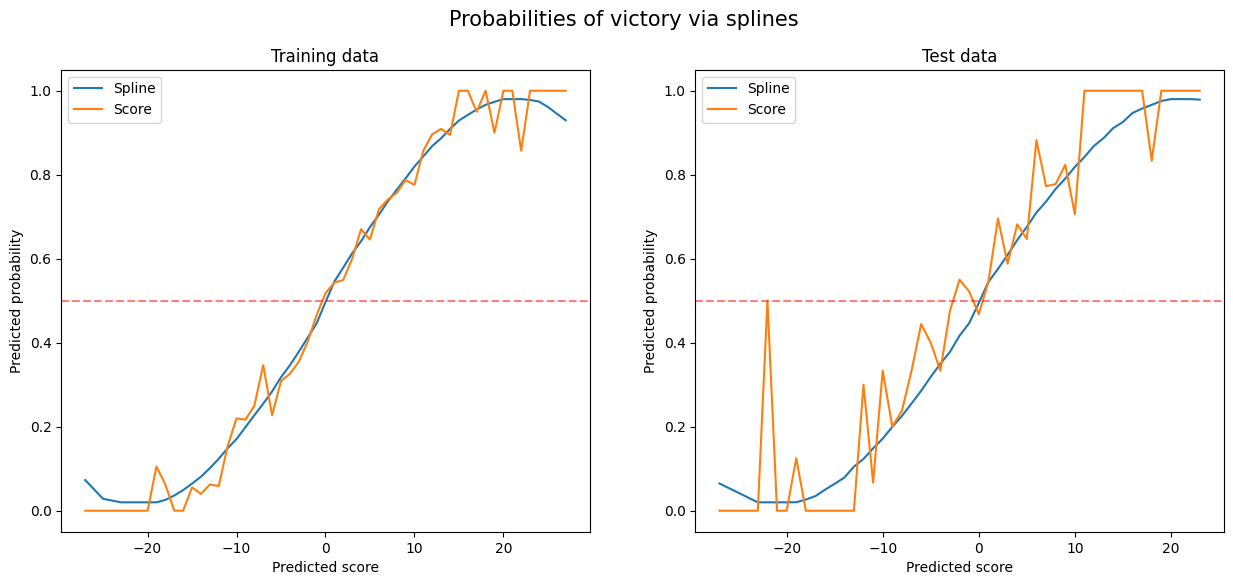

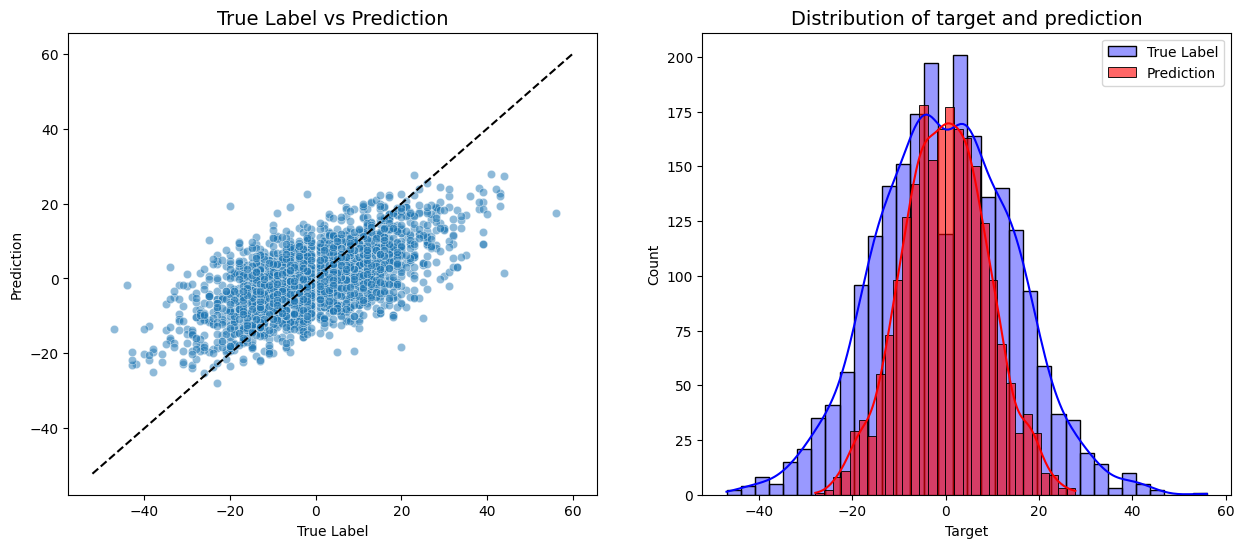

use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.


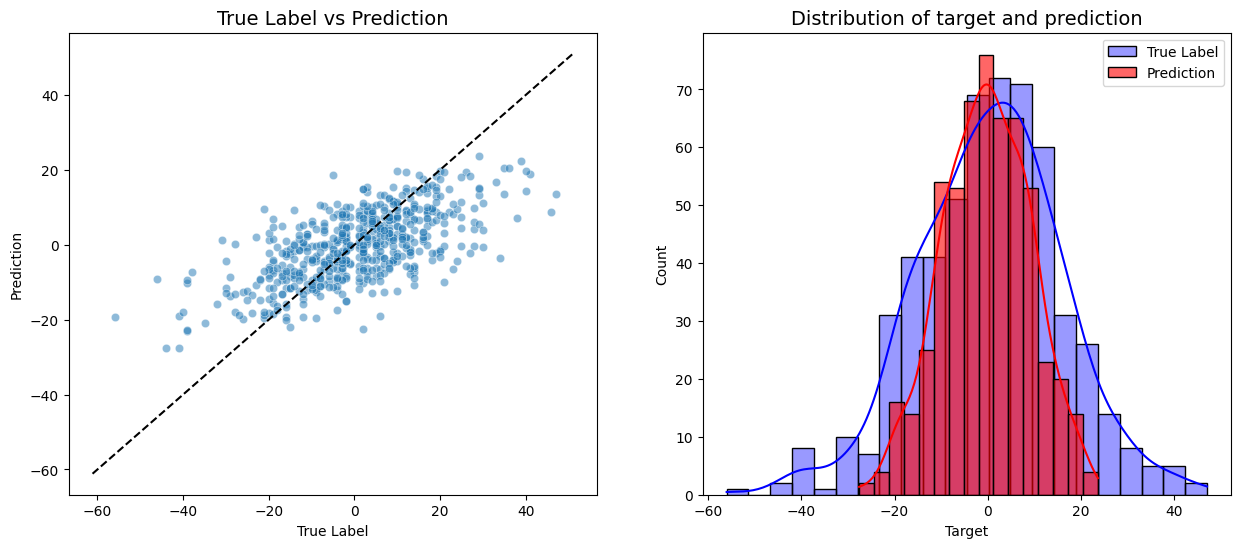

MAE train: 			 8.8758
MAE test: 			 9.146
RMSE train: 			 11.2962
RMSE test: 			 11.7843
Accuracy train: 		 0.7174
Accuracy test: 			 0.7158
Logloss train: 			 0.5432
Logloss test: 			 0.5409
Brier train: 			 0.184
Brier test: 			 0.1826
Unsure train: 			 16.47%
Unsure test: 			 16.55%


,mae_oof,mae_test,mse_oof,mse_test,acc_oof,acc_test,logloss_oof,logloss_test,brier_oof,brier_test,unsure_oof,unsure_test
0,8.8758,9.146,11.2962,11.7843,0.7174,0.7158,0.5432,0.5409,0.184,0.1826,16.47,16.55


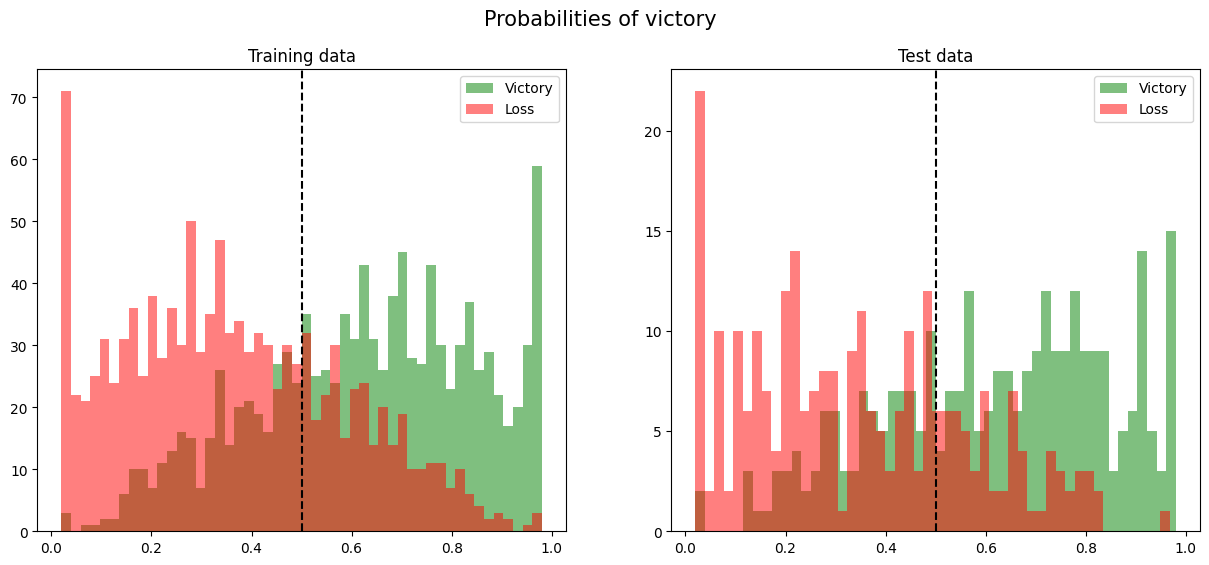

In [5]:
target = df_train["target_points"]

not_imp = [
 'delta_def_edge',
 'delta_OT_win',
 'delta_FGM',
 'delta_Ast_TO_ratio',
 'delta_OT_win_perc',
 'delta_FTA_diff',
 'delta_DR',
 'delta_opp_FTA',
 'delta_quality',
 'delta_Ast_diff',
 'delta_FTA',
 'delta_FTM',
 'delta_FTM_diff',
 'delta_DR_diff',
 'delta_Opp_eff_shooting_perc',
 'delta_Eff_shooting_perc',
 'delta_Ast',
 'delta_True_shooting_perc',
 'delta_TO',
 'delta_Stl',
 'delta_Score',
 'delta_PF_diff',
 'delta_OR',
 'delta_TO_diff',
 'delta_TO_perposs_diff',
 'delta_TO_perposs',
 'delta_off_rating_diff',
 'delta_opp_FGA',
 'delta_FGA3',
 'delta_opp_FGM',
 'delta_Tot_Reb_diff',
 'delta_True_shooting_perc_diff',
 'delta_def_rating',
 'delta_Tot_Reb',
 'delta_FGM3_diff',
 'delta_FGM3',
 'delta_FGA_diff',
 'delta_FGA3_diff',
 'delta_opp_score',
 'delta_possessions',
 'delta_opp_TO',
 'delta_opp_possessions',
 'delta_FG3_ratio',
 'delta_Eff_FG_perc_diff',
 'delta_FGA',
 'delta_FGA2',
 'delta_shtg_opportunity',
 'delta_FGA2_diff',
 'delta_FGM_no_ast_perc',
 'delta_FGM_perc']

extras = ['T1_Seed',
 'T1_elo',
 'T2_Seed',
 'T2_elo',]
FEATURES = [c for c in df_train if "delta" in c and c not in DROP ] #+ extras
train = df_train[FEATURES].copy()
test_target = df_test["target_points"]
test = df_test[FEATURES].copy()

model = Lasso(random_state=34, alpha=0.1, max_iter=10000)

pipe = Pipeline([
                ("scaler", tml.DfScaler()),
                ("model", model)])

oof, pred, result_dict = train_predict(data=train, test_data=test, target=target,
                                       estimator=pipe, cv=kfolds, test_target=test_target,
                                       fit_params=None, early_stopping=False,
                                       shap=True, result_compare=None)


report_points(train=df_train, test=df_test, y_train=target, y_test=test_target, oof=oof, preds=pred, clip_val=32, padd=0.02)

In [6]:
pred_oof, pred_test = _point_to_proba(oof=oof, y_train=df_train["target_points"], preds=pred)
df_train["oof"] = oof
df_train["oof_prob"] = pred_oof
df_test ["pred"] = pred
df_test["pred_prob"] = pred_test

df_train["abs_err_points"] = (df_train["target_points"] - df_train["oof"]).abs()
df_train["sqr_err_prob"] = (df_train["target"] - df_train["oof_prob"])**2
df_test["abs_err_points"] = (df_test["target_points"] - df_test["pred"]).abs()
df_test["sqr_err_prob"] = (df_test["target"] - df_test["pred_prob"])**2

In [7]:
df_train.groupby("stage_Round1")[["abs_err_points", "sqr_err_prob"]].mean()

,abs_err_points,sqr_err_prob
stage_Round1,,
False,9.064867,0.202230
True,8.691803,0.166185


In [8]:
df_train.groupby("stage_Round2")[["abs_err_points", "sqr_err_prob"]].mean()

,abs_err_points,sqr_err_prob
stage_Round2,,
False,8.830306,0.184815
True,9.009923,0.181459


In [9]:
df_train.groupby("stage_Round3")[["abs_err_points", "sqr_err_prob"]].mean()

,abs_err_points,sqr_err_prob
stage_Round3,,
False,8.835593,0.179233
True,9.154795,0.216777


In [10]:
df_train.groupby("stage_Round4")[["abs_err_points", "sqr_err_prob"]].mean()

,abs_err_points,sqr_err_prob
stage_Round4,,
False,8.856298,0.179059
True,9.168315,0.257475


In [11]:
df_train.groupby("stage_finalfour")[["abs_err_points", "sqr_err_prob"]].mean()

,abs_err_points,sqr_err_prob
stage_finalfour,,
False,8.844853,0.183242
True,9.774610,0.204928


In [12]:
df_train.groupby("stage_final")[["abs_err_points", "sqr_err_prob"]].mean()

,abs_err_points,sqr_err_prob
stage_final,,
False,8.889885,0.183879
True,7.970463,0.189460


In [18]:
# thrs = np.arange(0, 25)

# for th in thrs:
#     tmp = df_train.copy()
#     tmp.loc[(tmp["oof_prob"] > 0.5) & (tmp["oof_prob"] < 0.5 + th / 100) & (tmp["stage_final"]), "oof_prob"] = 0.5 + th / 100
#     tmp.loc[(tmp["oof_prob"] < 0.5) & (tmp["oof_prob"] > 0.5 - th / 100) & (tmp["stage_final"]), "oof_prob"] = 0.5 - th / 100
#     tmp["sqr_err_prob"] = (tmp["target"] - tmp["oof_prob"])**2

#     print(th, tmp["sqr_err_prob"].mean())

Round2 + 15%
Round4 + 9%

In [21]:
tmp = df_train.copy()
print(tmp["sqr_err_prob"].mean())
tmp.loc[(tmp["oof_prob"] > 0.5) & (tmp["oof_prob"] < 0.5 + 15 / 100) & (tmp["stage_Round2"]), "oof_prob"] = 0.5 + 15 / 100
tmp.loc[(tmp["oof_prob"] < 0.5) & (tmp["oof_prob"] > 0.5 - 15 / 100) & (tmp["stage_Round2"]), "oof_prob"] = 0.5 - 15 / 100
tmp.loc[(tmp["oof_prob"] > 0.5) & (tmp["oof_prob"] < 0.5 + 9 / 100) & (tmp["stage_Round4"]), "oof_prob"] = 0.5 + 9 / 100
tmp.loc[(tmp["oof_prob"] < 0.5) & (tmp["oof_prob"] > 0.5 - 9 / 100) & (tmp["stage_Round4"]), "oof_prob"] = 0.5 - 9 / 100
tmp["sqr_err_prob"] = (tmp["target"] - tmp["oof_prob"])**2
tmp["sqr_err_prob"].mean()


0.18396436480232392


0.1834826278955342

In [20]:
tmp = df_test.copy()
print(tmp["sqr_err_prob"].mean())
tmp.loc[(tmp["pred_prob"] > 0.5) & (tmp["pred_prob"] < 0.5 + 15 / 100) & (tmp["stage_Round2"]), "pred_prob"] = 0.5 + 15 / 100
tmp.loc[(tmp["pred_prob"] < 0.5) & (tmp["pred_prob"] > 0.5 - 15 / 100) & (tmp["stage_Round2"]), "pred_prob"] = 0.5 - 15 / 100
tmp.loc[(tmp["pred_prob"] > 0.5) & (tmp["pred_prob"] < 0.5 + 9 / 100) & (tmp["stage_Round4"]), "pred_prob"] = 0.5 + 9 / 100
tmp.loc[(tmp["pred_prob"] < 0.5) & (tmp["pred_prob"] > 0.5 - 9 / 100) & (tmp["stage_Round4"]), "pred_prob"] = 0.5 - 9 / 100
tmp["sqr_err_prob"] = (tmp["target"] - tmp["pred_prob"])**2
tmp["sqr_err_prob"].mean()

0.18251632901493048


0.18472579939293285

In [23]:
df_train.to_csv("data/results/men_train_lasso.csv", index=False)
df_test.to_csv("data/results/men_test_lasso.csv", index=False)